In [692]:
""" Import section """
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Opening files to analyze

In [693]:
""" Helper function to create a combined dataframe when given the group filepath"""
def create_combined_dataframe(group_filepath: str) -> pd.DataFrame:
    import os
    import glob

    # Get a list of all xlsx files in the specified directory
    files = glob.glob(os.path.join(group_filepath, "*.xlsx"))

    # Initialize an empty list to hold individual dataframes
    dataframes = []

    # Loop through each CSV file and read it into a dataframe
    for file in files:
        df = pd.read_excel(file)
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_dataframe = pd.concat(dataframes, ignore_index=True)

    return combined_dataframe

## DMSO Group

In [694]:
""" Group 0 -> Test Data, open all files and put them in a dataframe """

dmso  = create_combined_dataframe("dataset_t6_grouped/results/G0")
dmso.head(60)


""" Show only the highest "pbody_number" of the group 0 dataframe per image  """
dmso_highest_pbopdy = dmso.loc[dmso.groupby('image')['pbody_number'].idxmax()]
dmso_highest_pbopdy.tail(60)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
582,W0082F0002T0006Z000C1N151.png,14,30.166926,30.384852,17.621077,18.370207,DMSO,DMSO
523,W0082F0002T0006Z000C1N152.png,9,15.299378,17.473632,12.196866,13.832065,DMSO,DMSO
460,W0082F0002T0006Z000C1N153.png,4,21.716317,21.321122,19.366809,19.695328,DMSO,DMSO
308,W0082F0002T0006Z000C1N154.png,14,52.811247,53.188336,14.195958,14.128291,DMSO,DMSO
560,W0082F0002T0006Z000C1N156.png,9,45.651831,46.132974,10.033206,10.234657,DMSO,DMSO
739,W0082F0002T0006Z000C1N162.png,13,9.016816,8.400369,18.860760,20.080911,DMSO,DMSO
159,W0082F0002T0006Z000C1N19.png,7,63.970563,61.147552,12.358747,11.443836,DMSO,DMSO
684,W0082F0002T0006Z000C1N21.png,8,53.912650,55.723348,10.914597,10.558391,DMSO,DMSO
123,W0082F0002T0006Z000C1N30.png,7,62.780625,58.832797,9.280097,15.590544,DMSO,DMSO
909,W0082F0002T0006Z000C1N35.png,17,41.839969,41.666434,9.760894,9.811727,DMSO,DMSO


## Group 1

In [695]:
""" Group 1 -> Test Data, open all files and put them in a dataframe """

g1  = create_combined_dataframe("dataset_t6_grouped/results/G1")
# g1.head(50)

In [696]:
""" check for nan values on g1 dataframe """
g1.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 2

In [697]:
""" Group 2 -> Test Data, open all files and put them in a dataframe """

g2  = create_combined_dataframe("dataset_t6_grouped/results/G2")
# g2.head(50)


In [698]:
""" check for nan values on g2 dataframe """
g2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 3

In [699]:
""" Group 3 -> Test Data, open all files and put them in a dataframe """

g3  = create_combined_dataframe("dataset_t6_grouped/results/G3")
# g3.head(50)

In [700]:
""" check for nan values on g3 dataframe """
g3.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 4

In [701]:
""" Group 4 -> Test Data, open all files and put them in a dataframe """

g4  = create_combined_dataframe("dataset_t6_grouped/results/G4")
# g4.head(50)

In [702]:
""" check for nan values on g4 dataframe """
g4.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 5

In [703]:
""" Group 5 -> Test Data, open all files and put them in a dataframe """

g5  = create_combined_dataframe("dataset_t6_grouped/results/G5")
# g5.head(50)

In [704]:
""" check for nan values on g1 dataframe """
g5.isna().sum()

image            0
pbody_number     0
dist_nuclei     95
dist_mito        0
nuclei_std      95
mito_std         0
medicine         0
group            0
dtype: int64

# Graphing Section

In [705]:
""" Create a function that stores pbody number on dataframe"""


def summarize_pbodies_by_group(*dataframes):
    """
     The original dataframes structure:
      ['image', 'pbody_number', 'dist_nuclei', 'dist_mito',
       'nuclei_std', 'mito_std', 'medicine', 'group']
    """

    # --- Combine all dataframes into one ---
    combined_df = pd.concat(dataframes, ignore_index=True)

    # --- Summary per group ---
    group_summary = (
        combined_df.groupby('group')
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'),
                        std_dist_nuclei=('dist_nuclei', 'std'),
                        std_dist_mito=('dist_mito', 'std'))
                   .reset_index()
    )

    # --- Summary per group and medicine ---
    med_summary = (
        combined_df.groupby(['group', 'medicine'])
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'))
                   .reset_index()
    )

    return group_summary, med_summary, combined_df

In [706]:
""" Calling function for each dataframe """
group_summary, med_summary, combined_df = summarize_pbodies_by_group(dmso, g1, g2, g3, g4, g5)
group_summary.head(50)

,group,total_pbodies,mean_dist_nuclei,mean_dist_mito,std_dist_nuclei,std_dist_mito
0,DMSO,910,37.644022,35.330905,17.473040,17.331990
1,G1,1486,32.502657,29.817761,16.784150,16.022025
2,G2,2963,33.930727,33.009990,17.456573,17.135764
3,G3,1320,43.079189,41.130336,21.145230,21.348172
4,G4,7149,37.829421,34.953191,18.533707,18.679874
5,G5,5512,35.262373,29.232626,26.448808,24.425268


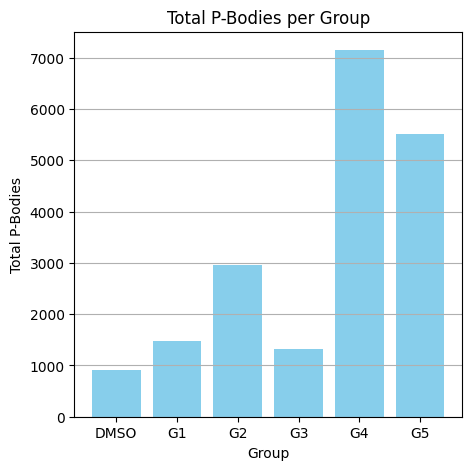

In [707]:
""" Boxplot creation: x-axis are count of pbodies and y-axis are groups. using group_summary dataframe (total_pbodies column) """
plt.figure(figsize=(5, 5))
plt.bar(group_summary['group'], group_summary['total_pbodies'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Total P-Bodies')
plt.title('Total P-Bodies per Group')
plt.xticks(group_summary['group'])
plt.grid(axis='y')
plt.show()

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/2166683291.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


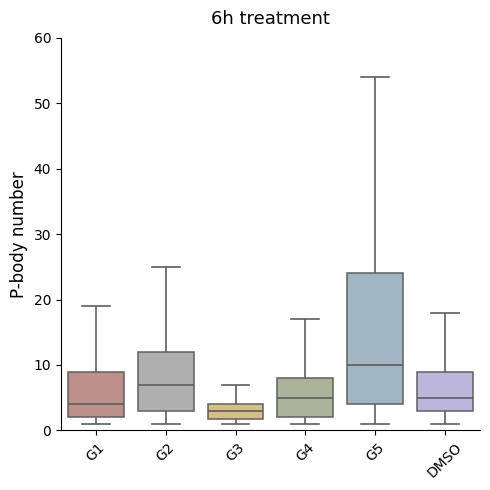

In [708]:
# --- reorder groups so DMSO is last ---
order = ["G1", "G2", "G3", "G4", "G5", "DMSO"]

# --- colors matching paper reference  ---
colors = ["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"]

# --- plot ---
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="pbody_number",
    data=combined_df,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)

# labels and aesthetics
plt.ylabel("P-body number", fontsize=12)
plt.xlabel("")
plt.title("6h treatment", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()

# --- add significance stars manually (adjust y-coordinates to your data) ---
annotations = ["***", "ns", "***", "*", "***"]
# for i, (label, g) in enumerate(zip(annotations, order[:-1])):
#     plt.text(i, y_max + 1, label, ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.ylim(0, 60)
plt.tight_layout()
plt.show()


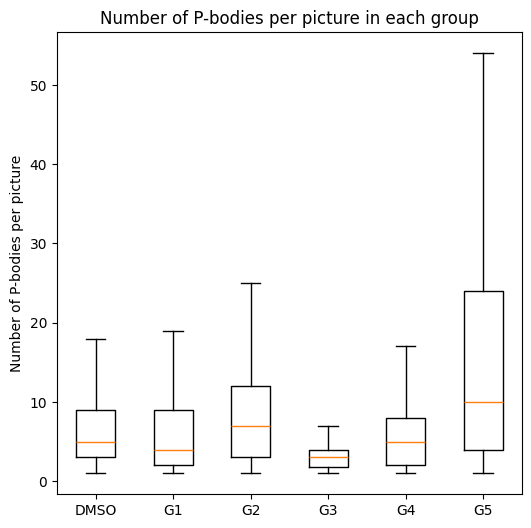

In [709]:
# Get unique group labels
groups = combined_df['group'].unique()

# Prepare data for each group
data_per_group = [
    combined_df.loc[combined_df['group'] == g, 'pbody_number'].values
    for g in groups
]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(data_per_group, tick_labels=groups, showfliers=False)
ax.set_ylabel('Number of P-bodies per picture')
ax.set_title('Number of P-bodies per picture in each group')
plt.show()


# Opening files to analyze2

In [710]:
""" Helper function to create a combined dataframe when given the group filepath"""
def create_combined_dataframe(group_filepath: str) -> pd.DataFrame:
    import os
    import glob

    # Get a list of all xlsx files in the specified directory
    files = glob.glob(os.path.join(group_filepath, "*.xlsx"))

    # Initialize an empty list to hold individual dataframes
    dataframes = []

    # Loop through each CSV file and read it into a dataframe
    for file in files:
        df = pd.read_excel(file)
        dataframes.append(df)

    # Concatenate all dataframes into a single dataframe
    combined_dataframe = pd.concat(dataframes, ignore_index=True)

    return combined_dataframe

## DMSO Group

In [711]:
""" Group 0 -> Test Data, open all files and put them in a dataframe """

dmso2  = create_combined_dataframe("dataset_t6_grouped/results2/G0")
dmso2.head(60)


""" Show only the highest "pbody_number" of the group 0 dataframe per image  """
dmso2_highest_pbopdy = dmso2.loc[dmso2.groupby('image')['pbody_number'].idxmax()]
dmso2_highest_pbopdy.tail(60)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
3319,W0082F0003T0006Z000C1N38.png,10,49.186208,51.773917,13.985013,13.278180,DMSO,DMSO
4,W0082F0003T0006Z000C1N39.png,5,39.175751,38.882883,6.095940,7.435404,DMSO,DMSO
1557,W0082F0003T0006Z000C1N4.png,21,41.055159,41.143215,13.196048,13.221340,DMSO,DMSO
1367,W0082F0003T0006Z000C1N40.png,4,4.928522,5.109031,20.551218,19.291494,DMSO,DMSO
2543,W0082F0003T0006Z000C1N41.png,20,54.550157,54.197891,18.599507,18.606962,DMSO,DMSO
1885,W0082F0003T0006Z000C1N42.png,12,73.001359,45.730768,22.737168,18.067667,DMSO,DMSO
1564,W0082F0003T0006Z000C1N43.png,7,38.727576,38.854408,23.153111,23.085020,DMSO,DMSO
1220,W0082F0003T0006Z000C1N44.png,9,36.042709,20.159542,21.146892,22.098380,DMSO,DMSO
2638,W0082F0003T0006Z000C1N45.png,6,48.270166,50.158777,9.987148,10.646326,DMSO,DMSO
2007,W0082F0003T0006Z000C1N46.png,10,39.482859,39.422166,11.180185,11.271965,DMSO,DMSO


## Group 1

In [712]:
""" Group 1 -> Test Data, open all files and put them in a dataframe """

g1_2  = create_combined_dataframe("dataset_t6_grouped/results2/G1")
# g1_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [713]:
""" check for nan values on g1 dataframe """
g1_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 2

In [714]:
""" Group 2 -> Test Data, open all files and put them in a dataframe """

g2_2  = create_combined_dataframe("dataset_t6_grouped/results2/G2")
# g2_2.head(50)


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [715]:
""" check for nan values on g2 dataframe """
g2_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 3

In [716]:
""" Group 3 -> Test Data, open all files and put them in a dataframe """

g3_2  = create_combined_dataframe("dataset_t6_grouped/results2/G3")
# g3_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [717]:
""" check for nan values on g3 dataframe """
g3_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     0
dist_mito       0
nuclei_std      0
mito_std        0
medicine        0
group           0
dtype: int64

## Group 4

In [718]:
""" Group 4 -> Test Data, open all files and put them in a dataframe """

g4_2  = create_combined_dataframe("dataset_t6_grouped/results2/G4")
# g4_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [719]:
""" check for nan values on g4 dataframe """
g4_2.isna().sum()

image           0
pbody_number    0
dist_nuclei     2
dist_mito       0
nuclei_std      2
mito_std        0
medicine        0
group           0
dtype: int64

## Group 5

In [720]:
""" Group 5 -> Test Data, open all files and put them in a dataframe """

g5_2  = create_combined_dataframe("dataset_t6_grouped/results2/G5")
# g5_2.head(50)

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/238873964.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_dataframe = pd.concat(dataframes, ignore_index=True)


In [721]:
""" check for nan values on g1 dataframe """
g5_2.isna().sum()

image             0
pbody_number      0
dist_nuclei     269
dist_mito         0
nuclei_std      269
mito_std          0
medicine          0
group             0
dtype: int64

# Graphing Section 2

In [722]:
""" Create a function that stores pbody number on dataframe"""


def summarize_pbodies_by_group(*dataframes):
    """
     The original dataframes structure:
      ['image', 'pbody_number', 'dist_nuclei', 'dist_mito',
       'nuclei_std', 'mito_std', 'medicine', 'group']
    """

    # --- Combine all dataframes into one ---
    combined_df = pd.concat(dataframes, ignore_index=True)

    # --- Summary per group ---
    group_summary = (
        combined_df.groupby('group')
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'),
                        std_dist_nuclei=('dist_nuclei', 'std'),
                        std_dist_mito=('dist_mito', 'std'))
                   .reset_index()
    )

    # --- Summary per group and medicine ---
    med_summary = (
        combined_df.groupby(['group', 'medicine'])
                   .agg(total_pbodies=('pbody_number', 'count'),
                        mean_dist_nuclei=('dist_nuclei', 'mean'),
                        mean_dist_mito=('dist_mito', 'mean'))
                   .reset_index()
    )

    return group_summary, med_summary, combined_df

In [723]:
""" Calling function for each dataframe """
group_summary_2, med_summary_2, combined_df_2 = summarize_pbodies_by_group(dmso2, g1_2, g2_2, g3_2, g4_2, g5_2)
group_summary_2.head(10)

,group,total_pbodies,mean_dist_nuclei,mean_dist_mito,std_dist_nuclei,std_dist_mito
0,DMSO,3573,36.733625,34.068509,17.797351,17.365795
1,G1,5429,32.239643,28.706005,16.822146,16.241783
2,G2,11288,35.318479,33.973716,17.623395,17.239116
3,G3,4734,41.488331,39.358789,21.306539,21.203340
4,G4,27425,37.304774,33.319227,18.474468,18.026102
5,G5,15826,37.949311,31.153032,25.419570,22.496226


In [724]:
med_summary_2.head(10)

,group,medicine,total_pbodies,mean_dist_nuclei,mean_dist_mito
0,DMSO,DMSO,3573,36.733625,34.068509
1,G1,T0374,617,28.664032,27.636065
2,G1,T0374L,224,27.826852,29.460203
3,G1,T1912,657,30.777818,28.852130
4,G1,T1995,678,31.510723,30.179122
5,G1,T6020,583,28.338502,25.676674
6,G1,T7394,2670,34.832755,29.141410
7,G2,T0860,1971,34.293371,33.295400
8,G2,T1448,2174,33.873300,32.225022
9,G2,T1656,1657,35.499692,33.806434


In [725]:
combined_df_2.head(10)

,image,pbody_number,dist_nuclei,dist_mito,nuclei_std,mito_std,medicine,group
0,W0082F0003T0006Z000C1N39.png,1,43.387036,52.802165,6.095940,7.435404,DMSO,DMSO
1,W0082F0003T0006Z000C1N39.png,2,49.414322,49.487081,6.095940,7.435404,DMSO,DMSO
2,W0082F0003T0006Z000C1N39.png,3,32.170167,32.546218,6.095940,7.435404,DMSO,DMSO
3,W0082F0003T0006Z000C1N39.png,4,46.954513,47.424503,6.095940,7.435404,DMSO,DMSO
4,W0082F0003T0006Z000C1N39.png,5,39.175751,38.882883,6.095940,7.435404,DMSO,DMSO
5,W0082F0002T0006Z000C1N159.png,1,35.480901,35.528320,10.819537,10.832505,DMSO,DMSO
6,W0082F0002T0006Z000C1N159.png,2,33.233617,33.190350,10.819537,10.832505,DMSO,DMSO
7,W0082F0002T0006Z000C1N159.png,3,27.171119,26.875309,10.819537,10.832505,DMSO,DMSO
8,W0082F0002T0006Z000C1N159.png,4,40.497247,40.428749,10.819537,10.832505,DMSO,DMSO
9,W0082F0002T0006Z000C1N159.png,5,46.406804,46.325366,10.819537,10.832505,DMSO,DMSO


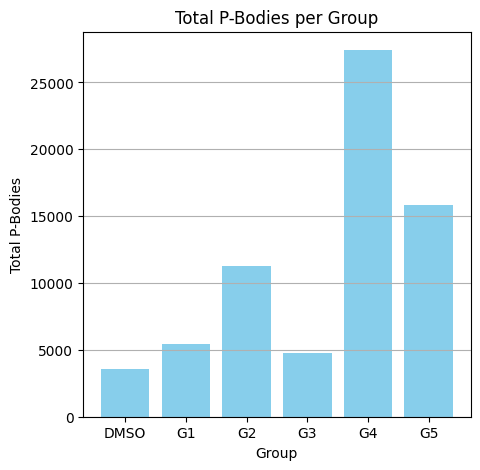

In [726]:
""" Boxplot creation: x-axis are count of pbodies and y-axis are groups. using group_summary dataframe (total_pbodies column) """
plt.figure(figsize=(5, 5))
plt.bar(group_summary_2['group'], group_summary_2['total_pbodies'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Total P-Bodies')
plt.title('Total P-Bodies per Group')
plt.xticks(group_summary_2['group'])
plt.grid(axis='y')
plt.show()

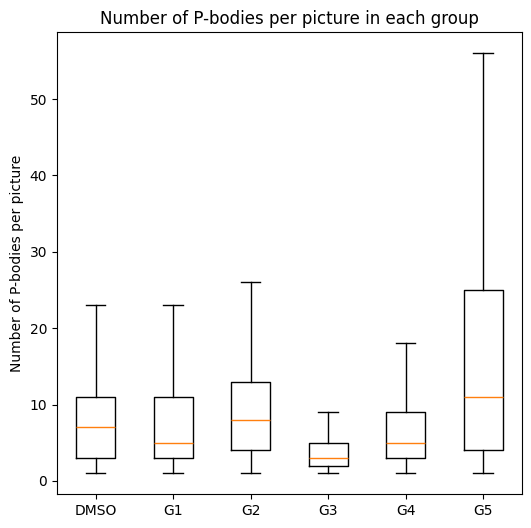

In [727]:
# Get unique group labels
groups = combined_df_2['group'].unique()

# Prepare data for each group
data_per_group_2 = [
    combined_df_2.loc[combined_df_2['group'] == g, 'pbody_number'].values
    for g in groups
]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.boxplot(data_per_group_2, tick_labels=groups, showfliers=False)
ax.set_ylabel('Number of P-bodies per picture')
ax.set_title('Number of P-bodies per picture in each group')
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/2770044040.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


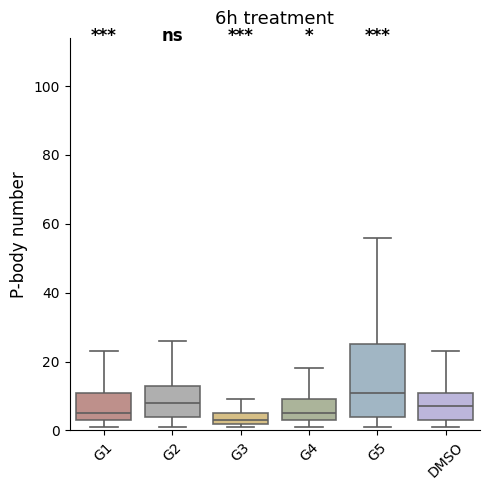

In [728]:
# --- reorder groups so DMSO is last ---
order = ["G1", "G2", "G3", "G4", "G5", "DMSO"]

# --- colors matching paper reference  ---
colors = ["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"]

# --- plot ---
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="pbody_number",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)

# labels and aesthetics
plt.ylabel("P-body number", fontsize=12)
plt.xlabel("")
plt.title("6h treatment", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()

# --- add significance stars manually (adjust y-coordinates to your data) ---
annotations = ["***", "ns", "***", "*", "***"]
y_max = combined_df_2["pbody_number"].max()
for i, (label, g) in enumerate(zip(annotations, order[:-1])):
    plt.text(i, y_max + 1, label, ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.ylim(0, y_max + 3)
plt.tight_layout()
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/1692681138.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


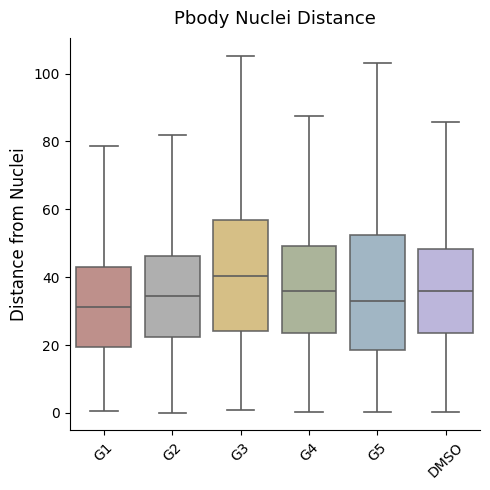

In [729]:
""" 
    Create A boxplot that shows the mean distance from nuclei per picture in each group using the combined_df_2 table
"""
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="dist_nuclei",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)
# labels and aesthetics
plt.ylabel("Distance from Nuclei", fontsize=12)
plt.xlabel("")
plt.title("Pbody Nuclei Distance", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()


# --- plot ---

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/3322048826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


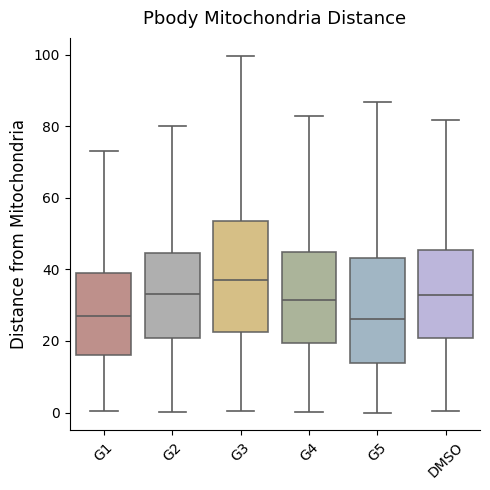

In [730]:
"""
    Create a boxplot that shows the mean distance from mitochondria per picture in each group using the combined_df_2 table 
"""
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="group",
    y="dist_mito",
    data=combined_df_2,
    order=order,
    palette=colors,
    showfliers=False,
    linewidth=1.2,
    boxprops=dict(alpha=0.9)
)
# labels and aesthetics
plt.ylabel("Distance from Mitochondria", fontsize=12)
plt.xlabel("")
plt.title("Pbody Mitochondria Distance", fontsize=13, pad=10)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

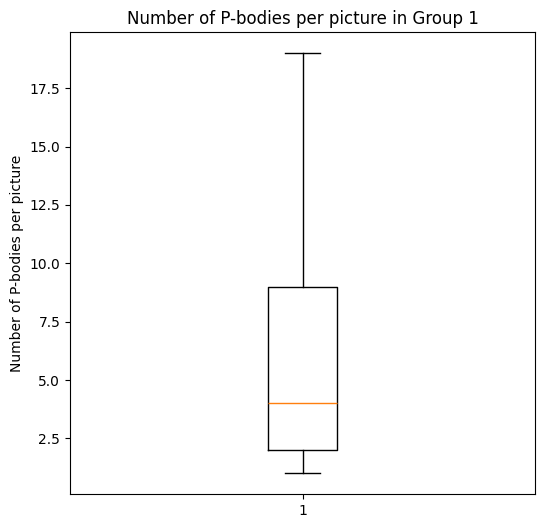

In [731]:
"""
    Graphing the number of pbodies by picture in group 1 using boxplot
"""

group_1_data = combined_df[combined_df['group'] == 'G1']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_1_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 1')
plt.show()


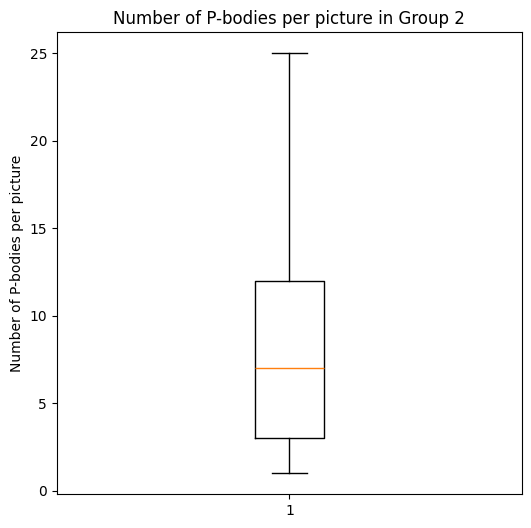

In [732]:
"""
    Graphing the number of pbodies by picture in group 2 using boxplot
"""

group_2_data = combined_df[combined_df['group'] == 'G2']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_2_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 2')
plt.show()

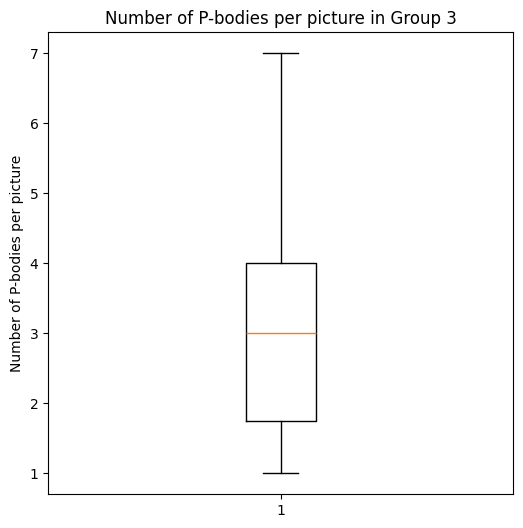

In [733]:
"""
    Graphing the number of pbodies by picture in group 3 using boxplot
"""

group_3_data = combined_df[combined_df['group'] == 'G3']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_3_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 3')
plt.show()

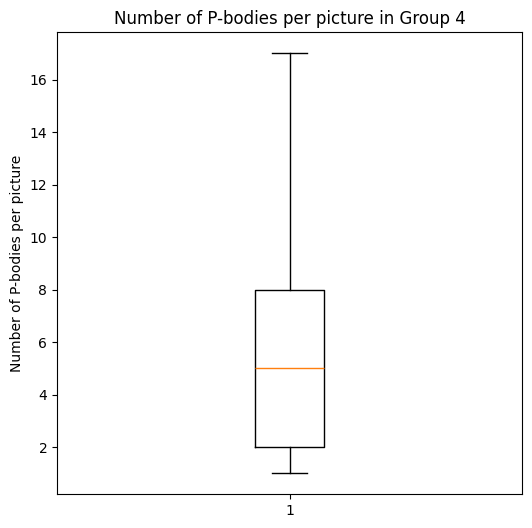

In [734]:
"""
    Graphing the number of pbodies by picture in group 4 using boxplot
"""

group_4_data = combined_df[combined_df['group'] == 'G4']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_4_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 4')
plt.show()

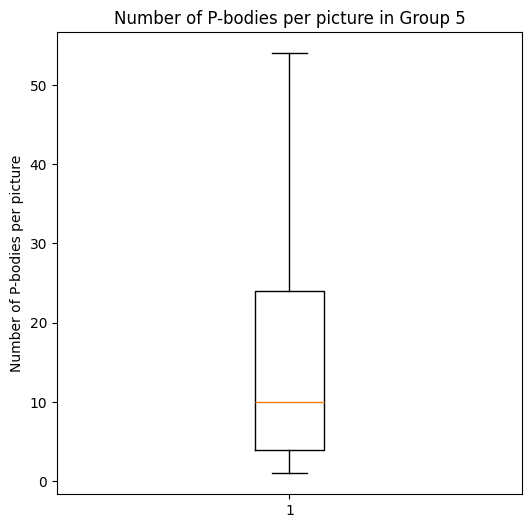

In [735]:
"""
    Graphing the number of pbodies by picture in group 4 using boxplot
"""

group_5_data = combined_df[combined_df['group'] == 'G5']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_5_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group 5')
plt.show()

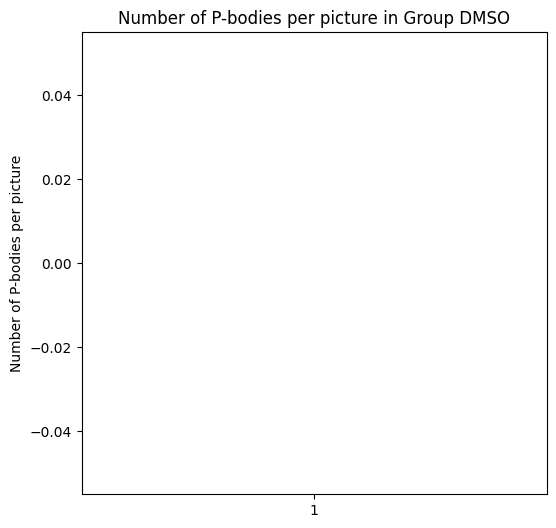

In [736]:
"""
    Graphing the number of pbodies by picture in group 0 using boxplot
"""

group_0_data = combined_df[combined_df['group'] == 'dmso']
fig = plt.figure(figsize =(6,6))
plt.boxplot(group_0_data['pbody_number'], showfliers=False)
plt.ylabel('Number of P-bodies per picture')
plt.title('Number of P-bodies per picture in Group DMSO')
plt.show()

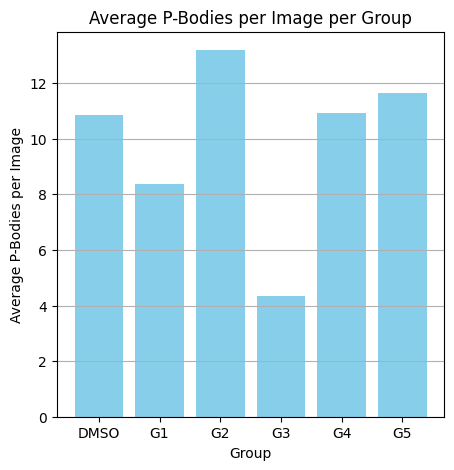

In [737]:
"""
    Boxplot of pbodies per group, calculated using the combined_df_2 dataframe and ensuring the average is calculated based on total pbody/number of images in each group
"""

# Calculate number of images per group
image_counts = combined_df_2.groupby('group')['image'].nunique().reset_index()
image_counts.columns = ['group', 'num_images']
# Merge image counts with group summary
group_summary_2 = group_summary_2.merge(image_counts, on='group')
# Calculate average pbodies per image
group_summary_2['avg_pbodies_per_image'] = group_summary_2['total_pbodies'] / group_summary_2['num_images']
# Boxplot creation
plt.figure(figsize=(5, 5))
plt.bar(group_summary_2['group'], group_summary_2['avg_pbodies_per_image'], color='skyblue')
plt.xlabel('Group')
plt.ylabel('Average P-Bodies per Image')
plt.title('Average P-Bodies per Image per Group')
plt.xticks(group_summary_2['group'])
plt.grid(axis='y')
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_65531/3215847997.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=group_labels, showfliers=False)


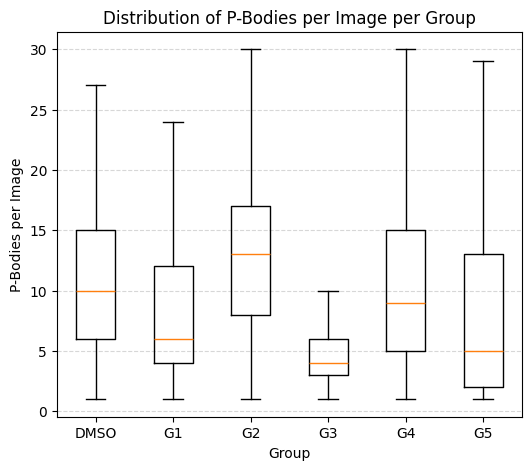

In [738]:
"""
    Boxplot of average pbodies per image in each group.
"""

# 1. Count pbodies per image
pbodies_per_image = (
    combined_df_2
    .groupby(['group', 'image'])['pbody_number']
    .count()
    .reset_index()
    .rename(columns={'pbody_number': 'pbodies_in_image'})
)

# 2. Create boxplot data structure
boxplot_data = [
    pbodies_per_image.loc[pbodies_per_image['group'] == g, 'pbodies_in_image'].values
    for g in sorted(pbodies_per_image['group'].unique())
]

group_labels = sorted(pbodies_per_image['group'].unique())

# 3. Plot boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(boxplot_data, labels=group_labels, showfliers=False)

plt.xlabel('Group')
plt.ylabel('P-Bodies per Image')
plt.title('Distribution of P-Bodies per Image per Group')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()
